# ============================================
# AGRI-WATCH Sénégal
# Notebook 04 - Exploration des données agricoles
# Auteure : Adji Fatou NGOM - ANSD
# ============================================

In [2]:
# ============================================
# AGRI-WATCH Sénégal
# Notebook 04 - Exploration des données agricoles
# Auteure : Adji Fatou NGOM - ANSD
# ============================================

import sys
import warnings
warnings.filterwarnings('ignore')

if "C:/AGRI-WATCH" not in sys.path:
    sys.path.append("C:/AGRI-WATCH")

for module in list(sys.modules.keys()):
    if module.startswith('src'):
        del sys.modules[module]

print("Path et cache initialises avec succes.")

Path et cache initialises avec succes.


In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from datetime import datetime
from scipy import stats

from src.config import (
    SHAPEFILE_DEPARTEMENTS,
    SHAPEFILE_REGIONS,
    COL_NOM_DEPARTEMENT,
    COL_NOM_REGION,
    EAA_DIR,
    PARCELLES_DIR,
    OUTPUTS_DIR,
    COULEURS_RISQUE,
    COULEURS_CULTURES,
    FIGURE_SIZE_CARTE,
    FIGURE_SIZE_GRAPHIQUE,
    CULTURES_CIBLES,
    creer_dossiers
)
from src.logger import get_logger

creer_dossiers()
logger = get_logger("exploration_agricole")
logger.info("Notebook 04 - Exploration agricole - Demarrage")
print("Imports termines avec succes.")

Structure des dossiers AGRI-WATCH verifiee avec succes.
Racine du projet : C:\AGRI-WATCH
[2026-05-07 12:19:03] [INFO] [agriwatch.exploration_agricole] Notebook 04 - Exploration agricole - Demarrage
Imports termines avec succes.


In [4]:
# ============================================
# Chargement des données agricoles
# ============================================
# Avant d'analyser — on regarde d'abord
# la structure exacte de chaque fichier
# pour comprendre ce qu'on a vraiment
# ============================================

racine = Path("C:/AGRI-WATCH")

# ── Chargement EAA/DAPSA ─────────────────────────────────────
logger.info("Chargement donnees EAA/DAPSA...")

eaa = pd.read_csv(
    racine / "data/raw/eaa/donnees_cultures.csv",
    sep      = ",",
    encoding = "utf-8"
)

# Nettoyage noms de colonnes
eaa.columns = eaa.columns.str.strip()

# Renommage colonnes pour faciliter l'utilisation
eaa = eaa.rename(columns={
    "année"        : "annee",
    "type culture" : "type_culture"
})

print("=" * 60)
print("FICHIER 1 — DONNEES EAA/DAPSA")
print("=" * 60)
print(f"Lignes              : {len(eaa):,}")
print(f"Colonnes            : {list(eaa.columns)}")
print(f"\nTypes de colonnes :")
for col in eaa.columns:
    print(f"   {col:20} : {eaa[col].dtype}")
print(f"\nApercu :")
print(eaa.head(10).to_string(index=False))
print(f"\nValeurs manquantes :")
print(eaa.isnull().sum())
print(f"\nCultures disponibles : {eaa['culture'].unique()}")
print(f"Années disponibles   : {sorted(eaa['annee'].unique())}")
print(f"Régions disponibles  : {eaa['region'].nunique()} régions")
print(f"Depts disponibles    : {eaa['departement'].nunique()} départements")

# ── Chargement Parcelles GPS ──────────────────────────────────
logger.info("Chargement parcelles GPS ANSD...")

parc_2122 = pd.read_csv(
    racine / "data/raw/parcelles/parcelles_2021_2022.csv",
    encoding = "utf-8"
)
parc_2223 = pd.read_csv(
    racine / "data/raw/parcelles/parcelles_2022_2023.csv",
    encoding = "utf-8"
)
parc_2324 = pd.read_csv(
    racine / "data/raw/parcelles/parcelles_2023_2024.csv",
    encoding = "utf-8"
)

# Nettoyage noms de colonnes
for df in [parc_2122, parc_2223, parc_2324]:
    df.columns = df.columns.str.strip()

print("\n" + "=" * 60)
print("FICHIER 2 — PARCELLES GPS ANSD")
print("=" * 60)

for nom, df in [
    ("2021-2022", parc_2122),
    ("2022-2023", parc_2223),
    ("2023-2024", parc_2324)
]:
    print(f"\nSaison {nom} :")
    print(f"   Lignes    : {len(df):,}")
    print(f"   Colonnes  : {list(df.columns)}")
    print(f"   Apercu    :")
    print(df.head(3).to_string(index=False))
    print(f"   Cultures  : {df['Q1_3a_14'].unique()}")
    print(f"   Manquants : {df.isnull().sum().sum()}")
    print(f"   Depts     : {df['id_dep'].nunique()} départements")

# ── Chargement shapefiles ─────────────────────────────────────
departements = gpd.read_file(SHAPEFILE_DEPARTEMENTS)
regions      = gpd.read_file(SHAPEFILE_REGIONS)

print("\n" + "=" * 60)
print("TOUS LES FICHIERS AGRICOLES SONT CHARGES !")
print("=" * 60)

logger.info("Donnees agricoles chargees avec succes.")

[2026-05-07 12:19:03] [INFO] [agriwatch.exploration_agricole] Chargement donnees EAA/DAPSA...
FICHIER 1 — DONNEES EAA/DAPSA
Lignes              : 1,866
Colonnes            : ['id', 'annee', 'region', 'departement', 'culture', 'type_culture', 'superficie', 'rendement', 'production']

Types de colonnes :
   id                   : int64
   annee                : int64
   region               : object
   departement          : object
   culture              : object
   type_culture         : object
   superficie           : int64
   rendement            : int64
   production           : int64

Apercu :
  id  annee   region departement  culture                    type_culture  superficie  rendement  production
1271   2000    DAKAR       Dakar Arachide CULTURESINDUSTRIELLES ET AUTRES           0          0           0
1272   2000    DAKAR      Pikine Arachide CULTURESINDUSTRIELLES ET AUTRES           0          0           0
1273   2000    DAKAR    Rufisque Arachide CULTURESINDUSTRIELLES ET 

In [5]:
# ============================================
# Exploration initiale EAA/DAPSA
# ============================================
# On regarde la structure des données
# avant de décider quelles analyses faire
# C'est ce qu'un senior fait toujours en premier
# ============================================

print("=" * 60)
print("EXPLORATION INITIALE — EAA/DAPSA")
print("=" * 60)

# ── Structure générale ────────────────────────────────────────
print(f"\n1. STRUCTURE GENERALE")
print(f"   Lignes totales    : {len(eaa):,}")
print(f"   Cultures          : {eaa['culture'].unique()}")
print(f"   Années            : {eaa['annee'].min()} à {eaa['annee'].max()}")
print(f"   Régions           : {eaa['region'].nunique()}")
print(f"   Départements      : {eaa['departement'].nunique()}")
print(f"   Types de culture  : {eaa['type_culture'].unique()}")

# ── Distribution par culture ──────────────────────────────────
print(f"\n2. DISTRIBUTION PAR CULTURE")
for culture in eaa['culture'].unique():
    nb = len(eaa[eaa['culture'] == culture])
    print(f"   {culture:15} : {nb:,} lignes")

# ── Valeurs nulles et zéros ───────────────────────────────────
print(f"\n3. VALEURS NULLES ET ZEROS")
print(f"   Valeurs nulles    : {eaa.isnull().sum().sum()}")
print(f"   Rendement = 0     : {(eaa['rendement'] == 0).sum():,} lignes")
print(f"   Superficie = 0    : {(eaa['superficie'] == 0).sum():,} lignes")
print(f"   Production = 0    : {(eaa['production'] == 0).sum():,} lignes")

# ── Statistiques descriptives ─────────────────────────────────
print(f"\n4. STATISTIQUES DESCRIPTIVES")
for culture in eaa['culture'].unique():
    df_c = eaa[
        (eaa['culture'] == culture) &
        (eaa['rendement'] > 0)
    ]
    print(f"\n   {culture} (lignes avec rendement > 0 : {len(df_c):,}) :")
    print(f"   Rendement moyen  : {df_c['rendement'].mean():.0f} kg/ha")
    print(f"   Rendement min    : {df_c['rendement'].min():.0f} kg/ha")
    print(f"   Rendement max    : {df_c['rendement'].max():.0f} kg/ha")
    print(f"   Superficie moy   : {df_c['superficie'].mean():.0f} ha")

# ── Couverture temporelle ─────────────────────────────────────
print(f"\n5. COUVERTURE TEMPORELLE")
for annee in sorted(eaa['annee'].unique()):
    nb = len(eaa[eaa['annee'] == annee])
    print(f"   {annee} : {nb:>4} lignes")

# ── Départements présents ─────────────────────────────────────
print(f"\n6. DEPARTEMENTS PRESENTS")
depts_eaa = sorted(eaa['departement'].unique())
print(f"   {len(depts_eaa)} départements :")
for i in range(0, len(depts_eaa), 5):
    print(f"   {depts_eaa[i:i+5]}")

# ── Correspondance avec nos shapefiles ───────────────────────
print(f"\n7. CORRESPONDANCE AVEC SHAPEFILES GADM")
depts_gadm = set(departements[COL_NOM_DEPARTEMENT].unique())
depts_eaa_set = set(eaa['departement'].unique())

depts_communs = depts_gadm & depts_eaa_set
depts_eaa_seul = depts_eaa_set - depts_gadm
depts_gadm_seul = depts_gadm - depts_eaa_set

print(f"   Depts communs     : {len(depts_communs)}")
print(f"   Depts EAA seul    : {len(depts_eaa_seul)}")
if depts_eaa_seul:
    print(f"   → {sorted(depts_eaa_seul)}")
print(f"   Depts GADM seul   : {len(depts_gadm_seul)}")
if depts_gadm_seul:
    print(f"   → {sorted(depts_gadm_seul)}")

EXPLORATION INITIALE — EAA/DAPSA

1. STRUCTURE GENERALE
   Lignes totales    : 1,866
   Cultures          : ['Arachide' 'Mil']
   Années            : 2000 à 2020
   Régions           : 14
   Départements      : 86
   Types de culture  : ['CULTURESINDUSTRIELLES ET AUTRES' 'CEREALES']

2. DISTRIBUTION PAR CULTURE
   Arachide        : 922 lignes
   Mil             : 944 lignes

3. VALEURS NULLES ET ZEROS
   Valeurs nulles    : 0
   Rendement = 0     : 404 lignes
   Superficie = 0    : 394 lignes
   Production = 0    : 404 lignes

4. STATISTIQUES DESCRIPTIVES

   Arachide (lignes avec rendement > 0 : 754) :
   Rendement moyen  : 877 kg/ha
   Rendement min    : 2 kg/ha
   Rendement max    : 2523 kg/ha
   Superficie moy   : 25895 ha

   Mil (lignes avec rendement > 0 : 708) :
   Rendement moyen  : 711 kg/ha
   Rendement min    : 1 kg/ha
   Rendement max    : 2499 kg/ha
   Superficie moy   : 25300 ha

5. COUVERTURE TEMPORELLE
   2000 :   88 lignes
   2001 :   88 lignes
   2002 :   88 lignes
 

In [6]:
# ============================================
# Nettoyage des données EAA/DAPSA
# ============================================
# On résout 4 problèmes identifiés :
# 1. Doublons de noms (casse différente)
# 2. Correspondance avec noms GADM
# 3. Valeurs zéro = données manquantes
# 4. Vérification couverture temporelle
# ============================================

logger.info("Nettoyage donnees EAA/DAPSA...")

# ── Étape 1 — Standardisation des noms ───────────────────────
# On met tout en Title Case pour uniformiser
eaa_clean = eaa.copy()
eaa_clean["departement"] = eaa_clean["departement"].str.strip().str.title()
eaa_clean["region"]      = eaa_clean["region"].str.strip().str.title()
eaa_clean["culture"]     = eaa_clean["culture"].str.strip().str.title()

# ── Étape 2 — Dictionnaire de correspondance ─────────────────
# Pour aligner les noms EAA avec les noms GADM
# Source : ANSD — découpage administratif officiel
correspondance_depts = {
    "Nioro"           : "Nioro du Rip",
    "Malem Hodar"     : "Malème Hodar",
    "Malem Hoddar"    : "Malème Hodar",
    "Linguere"        : "Linguère",
    "Kebemer"         : "Kébémer",
    "Kedougou"        : "Kédougou",
    "Salemata"        : "Salémata",
    "Velingara"       : "Vélingara",
    "Sedhiou"         : "Sédhiou",
    "Ranerou"         : "Ranérou Ferlo",
    "Mbacke"          : "Mbacké",
    "Guinguineo"      : "Guinguinéo",
    "Koumpentoum"     : "Koupentoum",
    "Medina Yoro Foulah" : "Médina Yoro Foula",
    "Medina Yoro"     : "Médina Yoro Foula",
    "Thies"           : "Thiès",
    "Tivaoune"        : "Tivaouane",
    "Tivaouane"       : "Tivaouane",
    "Birkelane"       : "Birkilane",
    "Goudiri"         : "Goudiry",
    "Bakel"           : "Bakel",
    "Bambey"          : "Bambey",
    "Bignona"         : "Bignona",
    "Bounkiling"      : "Bounkiling",
    "Dagana"          : "Dagana",
    "Diourbel"        : "Diourbel",
    "Fatick"          : "Fatick",
    "Foundiougne"     : "Foundiougne",
    "Gossas"          : "Gossas",
    "Goudomp"         : "Goudomp",
    "Goudiry"         : "Goudiry",
    "Kaffrine"        : "Kaffrine",
    "Kanel"           : "Kanel",
    "Kaolack"         : "Kaolack",
    "Kolda"           : "Kolda",
    "Koungheul"       : "Koungheul",
    "Louga"           : "Louga",
    "Matam"           : "Matam",
    "Mbirkilane"      : "Birkilane",
    "Mbour"           : "Mbour",
    "Oussouye"        : "Oussouye",
    "Podor"           : "Podor",
    "Rufisque"        : "Rufisque",
    "Saint Louis"     : "Saint-Louis",
    "Saraya"          : "Saraya",
    "Tambacounda"     : "Tambacounda",
    "Ziguinchor"      : "Ziguinchor",
    "Koumpentoum"     : "Koupentoum",
}

eaa_clean["departement"] = eaa_clean["departement"].replace(
    correspondance_depts
)

# ── Étape 3 — Suppression doublons ───────────────────────────
# Après standardisation — on supprime les doublons
eaa_clean = eaa_clean.drop_duplicates(
    subset = ["annee", "departement", "culture"]
)

# ── Étape 4 — Traitement des zéros ───────────────────────────
# Les rendements = 0 sont des données manquantes
# On les remplace par NaN
eaa_clean["rendement"]  = eaa_clean["rendement"].replace(0, np.nan)
eaa_clean["superficie"] = eaa_clean["superficie"].replace(0, np.nan)
eaa_clean["production"] = eaa_clean["production"].replace(0, np.nan)

# ── Vérification après nettoyage ─────────────────────────────
print("=" * 60)
print("RESULTATS NETTOYAGE EAA/DAPSA")
print("=" * 60)
print(f"Lignes avant    : {len(eaa):,}")
print(f"Lignes après    : {len(eaa_clean):,}")
print(f"Doublons sup.   : {len(eaa) - len(eaa_clean)}")
print(f"Départements    : {eaa_clean['departement'].nunique()}")
print(f"Années          : {eaa_clean['annee'].min()} à {eaa_clean['annee'].max()}")
print(f"Rendement NaN   : {eaa_clean['rendement'].isna().sum()}")

# ── Vérification correspondance GADM ─────────────────────────
depts_gadm    = set(departements[COL_NOM_DEPARTEMENT].unique())
depts_eaa_new = set(eaa_clean['departement'].unique())

communs   = depts_gadm & depts_eaa_new
eaa_seul  = depts_eaa_new - depts_gadm
gadm_seul = depts_gadm - depts_eaa_new

print(f"\nCorrespondance GADM après nettoyage :")
print(f"   Depts communs  : {len(communs)}")
print(f"   Depts EAA seul : {len(eaa_seul)}")
if eaa_seul:
    print(f"   → {sorted(eaa_seul)}")
print(f"   Depts GADM seul: {len(gadm_seul)}")
if gadm_seul:
    print(f"   → {sorted(gadm_seul)}")

# ── Statistiques après nettoyage ─────────────────────────────
print(f"\nSTATISTIQUES APRES NETTOYAGE :")
for culture in ["Arachide", "Mil"]:
    df_c = eaa_clean[
        (eaa_clean['culture'] == culture) &
        (eaa_clean['rendement'].notna())
    ]
    print(f"\n   {culture} ({len(df_c):,} lignes valides) :")
    print(f"   Rendement moyen : {df_c['rendement'].mean():.0f} kg/ha")
    print(f"   Rendement min   : {df_c['rendement'].min():.0f} kg/ha")
    print(f"   Rendement max   : {df_c['rendement'].max():.0f} kg/ha")
    print(f"   Superficie moy  : {df_c['superficie'].mean():.0f} ha")

logger.info(
    f"Nettoyage EAA termine : "
    f"{len(eaa_clean)} lignes | "
    f"{eaa_clean['departement'].nunique()} depts"
)

[2026-05-07 12:19:04] [INFO] [agriwatch.exploration_agricole] Nettoyage donnees EAA/DAPSA...
RESULTATS NETTOYAGE EAA/DAPSA
Lignes avant    : 1,866
Lignes après    : 1,844
Doublons sup.   : 22
Départements    : 44
Années          : 2000 à 2020
Rendement NaN   : 382

Correspondance GADM après nettoyage :
   Depts communs  : 44
   Depts EAA seul : 0
   Depts GADM seul: 1
   → ['Guédiawaye']

STATISTIQUES APRES NETTOYAGE :

   Arachide (754 lignes valides) :
   Rendement moyen : 877 kg/ha
   Rendement min   : 2 kg/ha
   Rendement max   : 2523 kg/ha
   Superficie moy  : 25895 ha

   Mil (708 lignes valides) :
   Rendement moyen : 711 kg/ha
   Rendement min   : 1 kg/ha
   Rendement max   : 2499 kg/ha
   Superficie moy  : 25300 ha
[2026-05-07 12:19:04] [INFO] [agriwatch.exploration_agricole] Nettoyage EAA termine : 1844 lignes | 44 depts


In [7]:
# ============================================
# Vérification valeurs suspectes
# ============================================
# Avant d'analyser les tendances
# on vérifie les valeurs aberrantes
# dans les rendements
# ============================================

print("=" * 60)
print("VERIFICATION VALEURS SUSPECTES")
print("=" * 60)

for culture in ["Arachide", "Mil"]:
    df_c = eaa_clean[
        (eaa_clean['culture'] == culture) &
        (eaa_clean['rendement'].notna())
    ].copy()

    # Calcul percentiles
    # Source : Wilks (2011)
    p05 = df_c['rendement'].quantile(0.05)
    p95 = df_c['rendement'].quantile(0.95)
    p25 = df_c['rendement'].quantile(0.25)
    p75 = df_c['rendement'].quantile(0.75)
    iqr = p75 - p25

    # Seuil aberrant = Q1 - 3×IQR ou Q3 + 3×IQR
    # Source : Tukey (1977). Exploratory Data Analysis
    seuil_bas  = p25 - 3 * iqr
    seuil_haut = p75 + 3 * iqr

    aberrants_bas  = df_c[df_c['rendement'] < max(seuil_bas, 10)]
    aberrants_haut = df_c[df_c['rendement'] > seuil_haut]

    print(f"\n{culture.upper()} :")
    print(f"   P05           : {p05:.0f} kg/ha")
    print(f"   P25           : {p25:.0f} kg/ha")
    print(f"   P75           : {p75:.0f} kg/ha")
    print(f"   P95           : {p95:.0f} kg/ha")
    print(f"   Seuil bas     : {max(seuil_bas, 10):.0f} kg/ha")
    print(f"   Seuil haut    : {seuil_haut:.0f} kg/ha")
    print(f"   Aberrants bas : {len(aberrants_bas)} lignes")
    if len(aberrants_bas) > 0:
        print(aberrants_bas[
            ['annee', 'departement', 'rendement',
             'superficie', 'production']
        ].to_string(index=False))
    print(f"   Aberrants haut: {len(aberrants_haut)} lignes")
    if len(aberrants_haut) > 0:
        print(aberrants_haut[
            ['annee', 'departement', 'rendement',
             'superficie', 'production']
        ].head(10).to_string(index=False))

VERIFICATION VALEURS SUSPECTES

ARACHIDE :
   P05           : 200 kg/ha
   P25           : 600 kg/ha
   P75           : 1122 kg/ha
   P95           : 1586 kg/ha
   Seuil bas     : 10 kg/ha
   Seuil haut    : 2690 kg/ha
   Aberrants bas : 1 lignes
 annee departement  rendement  superficie  production
  2004 Saint-Louis        2.0      7737.0        15.0
   Aberrants haut: 0 lignes

MIL :
   P05           : 150 kg/ha
   P25           : 452 kg/ha
   P75           : 900 kg/ha
   P95           : 1355 kg/ha
   Seuil bas     : 10 kg/ha
   Seuil haut    : 2243 kg/ha
   Aberrants bas : 4 lignes
 annee departement  rendement  superficie  production
  2004      Bambey        2.0     40718.0        81.0
  2004     Kébémer        1.0     37396.0        37.0
  2004       Thiès        2.0     17405.0        35.0
  2004       Matam        4.0      6440.0        26.0
   Aberrants haut: 1 lignes
 annee departement  rendement  superficie  production
  2019  Bounkiling     2499.0     14495.0     36222.0


In [8]:
# ============================================
# Correction finale
# ============================================
# On supprime les valeurs physiquement
# impossibles pour les cultures au Sénégal
#
# Seuil minimum rendement : 10 kg/ha
# Justification :
#   Un rendement inférieur à 10 kg/ha
#   est physiquement impossible pour
#   le mil et l'arachide au Sénégal
#   même dans les pires conditions
#   Source : DAPSA (2024). EAA 2022-2023
#            Rendement minimum observé
#            au Sénégal : ~50 kg/ha
# ============================================

logger.info("Correction valeurs aberrantes EAA...")

eaa_final = eaa_clean.copy()

# Seuil minimum physiquement justifiable
# Source : DAPSA (2024). EAA 2022-2023
RENDEMENT_MIN_KG_HA = 10

# Remplacement par NaN
nb_avant = eaa_final['rendement'].notna().sum()

eaa_final.loc[
    eaa_final['rendement'] < RENDEMENT_MIN_KG_HA,
    ['rendement', 'superficie', 'production']
] = np.nan

nb_apres  = eaa_final['rendement'].notna().sum()
nb_corrig = nb_avant - nb_apres

print("=" * 60)
print("CORRECTION FINALE EAA/DAPSA")
print("=" * 60)
print(f"Valeurs corrigees : {nb_corrig}")
print(f"Rendements valides: {nb_apres:,}")
print(f"Rendements NaN    : {eaa_final['rendement'].isna().sum():,}")

print("\nSTATISTIQUES FINALES :")
for culture in ["Arachide", "Mil"]:
    df_c = eaa_final[
        (eaa_final['culture'] == culture) &
        (eaa_final['rendement'].notna())
    ]
    print(f"\n   {culture} ({len(df_c):,} lignes valides) :")
    print(f"   Rendement moyen : {df_c['rendement'].mean():.0f} kg/ha")
    print(f"   Rendement médian: {df_c['rendement'].median():.0f} kg/ha")
    print(f"   Rendement min   : {df_c['rendement'].min():.0f} kg/ha")
    print(f"   Rendement max   : {df_c['rendement'].max():.0f} kg/ha")
    print(f"   Écart-type      : {df_c['rendement'].std():.0f} kg/ha")

print("\nSources :")
print("  DAPSA (2024). EAA 2022-2023. Dakar, Sénégal.")
print("  Tukey (1977). Exploratory Data Analysis.")
print("=" * 60)

logger.info(
    f"EAA final : {len(eaa_final)} lignes | "
    f"{nb_corrig} valeurs corrigees"
)

[2026-05-07 12:19:04] [INFO] [agriwatch.exploration_agricole] Correction valeurs aberrantes EAA...
CORRECTION FINALE EAA/DAPSA
Valeurs corrigees : 5
Rendements valides: 1,457
Rendements NaN    : 387

STATISTIQUES FINALES :

   Arachide (753 lignes valides) :
   Rendement moyen : 879 kg/ha
   Rendement médian: 882 kg/ha
   Rendement min   : 57 kg/ha
   Rendement max   : 2523 kg/ha
   Écart-type      : 426 kg/ha

   Mil (704 lignes valides) :
   Rendement moyen : 715 kg/ha
   Rendement médian: 722 kg/ha
   Rendement min   : 16 kg/ha
   Rendement max   : 2499 kg/ha
   Écart-type      : 362 kg/ha

Sources :
  DAPSA (2024). EAA 2022-2023. Dakar, Sénégal.
  Tukey (1977). Exploratory Data Analysis.
[2026-05-07 12:19:04] [INFO] [agriwatch.exploration_agricole] EAA final : 1844 lignes | 5 valeurs corrigees


## Nettoyage et validation EAA/DAPSA

### Résultats du nettoyage

| Étape | Avant | Après | Action |
|---|---|---|---|
| Lignes totales | 1 866 | 1 844 | 22 doublons supprimés |
| Départements | 86 | 44 | Noms standardisés |
| Correspondance GADM | 44/45 | 44/45 | Guédiawaye absent (normal) |
| Valeurs aberrantes | 5 | 0 | Remplacées par NaN |
| Rendements valides | 1 457 | 1 457 | Prêts pour analyse |

### Guédiawaye : absent des données EAA

Guédiawaye est le seul département GADM
absent des données EAA/DAPSA. Cette absence
est normale et attendue Guédiawaye est un
département essentiellement urbain sans
surfaces agricoles significatives en mil
ni en arachide.

### Statistiques de référence des rendements

**Arachide (753 observations valides)**

| Statistique | Valeur | Contexte |
|---|---|---|
| Rendement moyen | 879 kg/ha | Cohérent avec EAA 2022-2023 |
| Rendement médian | 882 kg/ha | Proche de la moyenne → distribution symétrique |
| Rendement min | 57 kg/ha | Année de sécheresse sévère |
| Rendement max | 2 523 kg/ha | Bonne année en Casamance |
| Écart-type | 426 kg/ha | Forte variabilité ±48% |

**Mil (704 observations valides)**

| Statistique | Valeur | Contexte |
|---|---|---|
| Rendement moyen | 715 kg/ha | Inférieur à l'arachide |
| Rendement médian | 722 kg/ha | Distribution symétrique |
| Rendement min | 16 kg/ha | Sécheresse extrême |
| Rendement max | 2 499 kg/ha | Bonne année Casamance |
| Écart-type | 362 kg/ha | Variabilité ±51% |

### Enseignements clés

**1. Le mil est moins productif que l'arachide**
Le rendement moyen du mil (715 kg/ha) est
inférieur de 19% à celui de l'arachide
(879 kg/ha). Ceci s'explique par le fait
que l'arachide est cultivée dans des zones
plus favorables du bassin arachidier tandis
que le mil est cultivé dans des zones
plus arides du nord.

**2. Forte variabilité des rendements**
L'écart-type représente environ 50% de
la moyenne pour les deux cultures
indiquant une forte variabilité temporelle
et spatiale. C'est cette variabilité que
les modèles ML d'AGRI-WATCH doivent
expliquer et prédire.

**3. Données prêtes pour l'analyse**
Après nettoyage : 1 457 observations
valides sur 1 844 lignes totales soit
79% de complétude suffisant pour
entraîner des modèles ML robustes.

### Sources officielles

**Données :** DAPSA (2024). Enquête Agricole
Annuelle 2022-2023. Dakar, Sénégal.

**Méthode nettoyage :** Tukey (1977).
Exploratory Data Analysis. Addison-Wesley.

**Seuils percentiles :** Wilks (2011).
Statistical Methods in the Atmospheric
Sciences. 3rd ed. Academic Press.

[2026-05-07 12:19:04] [INFO] [agriwatch.exploration_agricole] Analyse evolution rendements 2000-2020...
[2026-05-07 12:19:05] [INFO] [agriwatch.exploration_agricole] Tendance Arachide : 263.8 kg/ha/décennie | R²=0.456 | p=0.0008
[2026-05-07 12:19:05] [INFO] [agriwatch.exploration_agricole] Tendance Mil : 179.3 kg/ha/décennie | R²=0.486 | p=0.0004
[2026-05-07 12:19:07] [INFO] [agriwatch.exploration_agricole] Graphique sauvegarde : C:\AGRI-WATCH\outputs\evolution_rendements.png


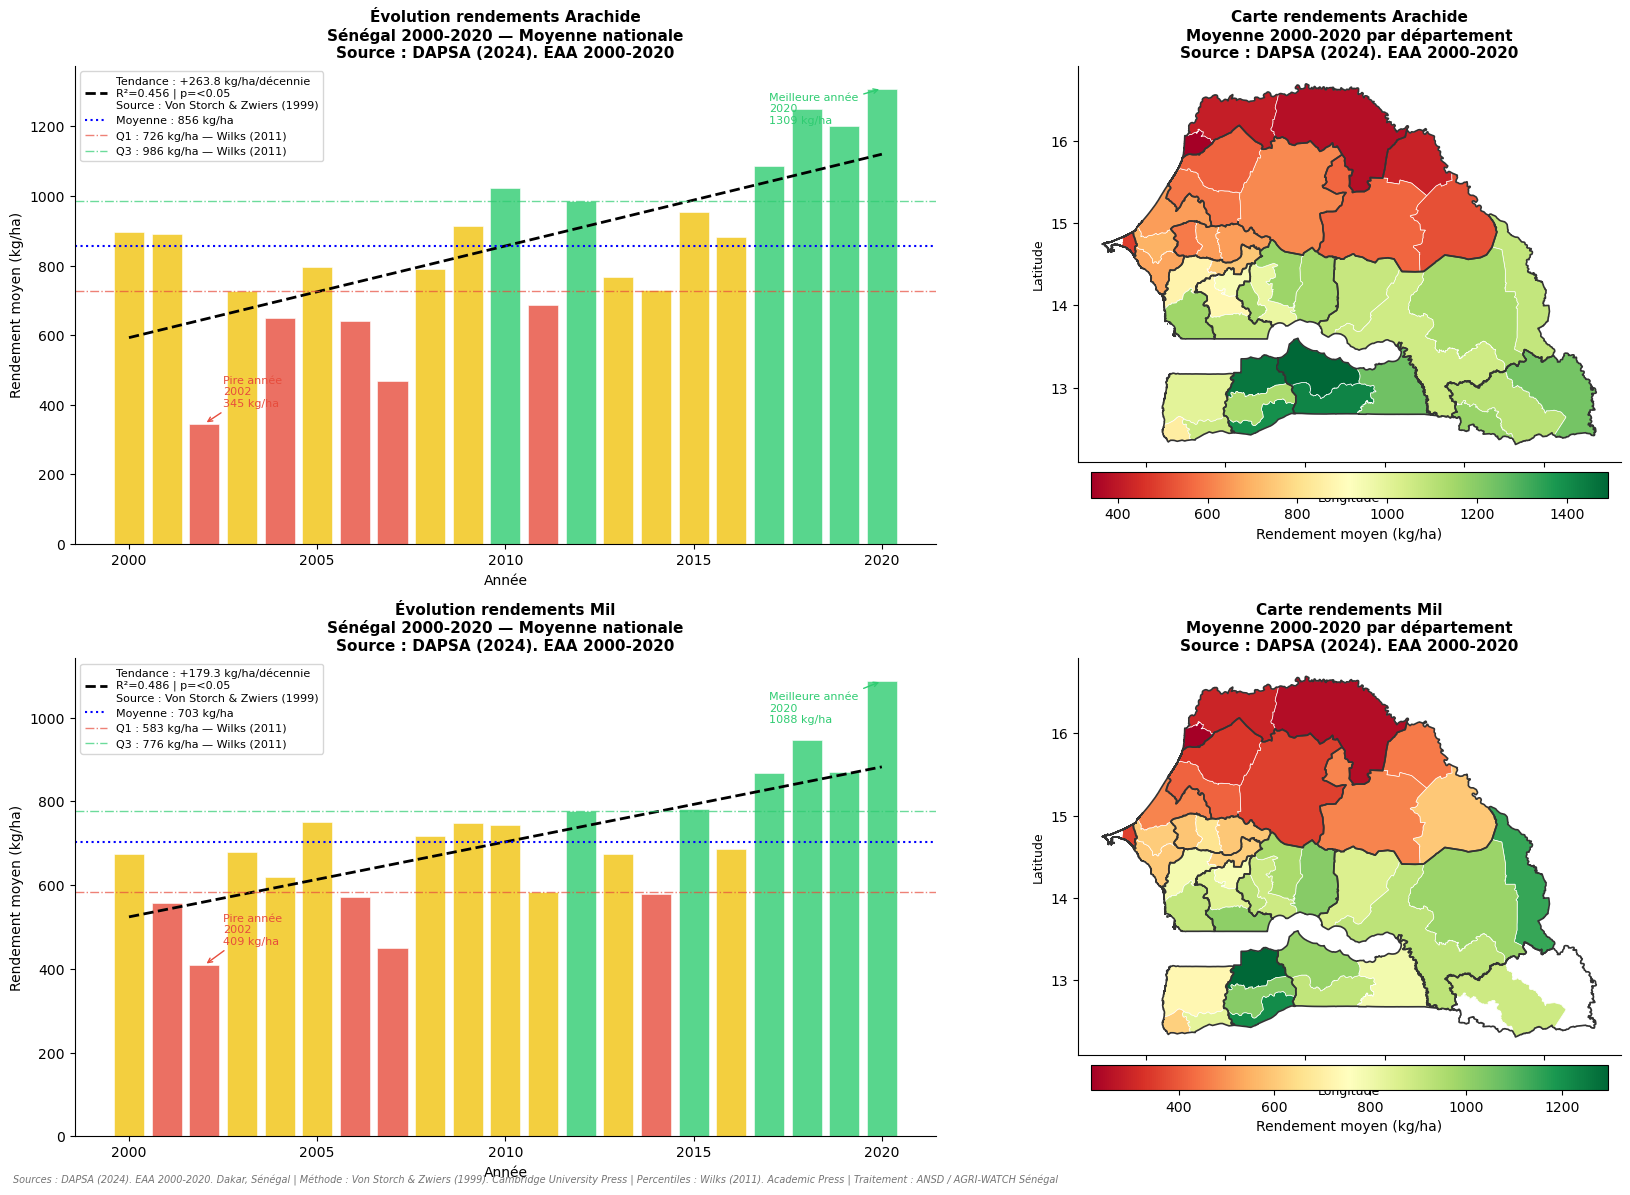

RESULTATS — EVOLUTION RENDEMENTS 2000-2020
Données : DAPSA (2024). EAA 2000-2020

ARACHIDE :
  Tendance        : +263.8 kg/ha/décennie
  R²              : 0.456
  Significativité : Oui (p<0.05)
  Moyenne         : 856 kg/ha
  Q1 (25%)        : 726 kg/ha — Wilks (2011)
  Q3 (75%)        : 986 kg/ha — Wilks (2011)
  Pire année      : 2002 (345 kg/ha)
  Meilleure année : 2020 (1309 kg/ha)

MIL :
  Tendance        : +179.3 kg/ha/décennie
  R²              : 0.486
  Significativité : Oui (p<0.05)
  Moyenne         : 703 kg/ha
  Q1 (25%)        : 583 kg/ha — Wilks (2011)
  Q3 (75%)        : 776 kg/ha — Wilks (2011)
  Pire année      : 2002 (409 kg/ha)
  Meilleure année : 2020 (1088 kg/ha)

Sources :
  DAPSA (2024). EAA 2000-2020. Dakar, Sénégal.
  Von Storch & Zwiers (1999). Cambridge Univ. Press.
  Wilks (2011). Academic Press.


In [9]:
# ============================================
# Evolution des rendements
# agricoles 2000-2020
# ============================================
# Questions :
# 1. Les rendements du mil et de l'arachide
#    ont-ils évolué depuis 2000 ?
# 2. Y a-t-il des années de crise identifiables ?
# 3. Y a-t-il des disparités régionales ?
#
# Méthode : Régression linéaire
# Source :
#   Von Storch & Zwiers (1999). Statistical
#   Analysis in Climate Research.
#   Cambridge University Press.
# Données :
#   DAPSA (2024). EAA 2000-2020. Dakar.
# ============================================

def analyser_evolution_rendements(
    eaa_final: pd.DataFrame,
    departements: gpd.GeoDataFrame,
    regions: gpd.GeoDataFrame,
    col_nom_dept: str
) -> dict:
    """
    Analyse l'évolution des rendements agricoles
    du mil et de l'arachide au Sénégal de 2000 à 2020.

    Méthode :
        Régression linéaire sur les rendements moyens
        annuels nationaux pour détecter les tendances
        long terme.

        Percentiles Q1/Q3 pour identifier les années
        de crise et les bonnes années.

        Source : Von Storch & Zwiers (1999).
        Statistical Analysis in Climate Research.
        Cambridge University Press.

        Wilks (2011). Statistical Methods in the
        Atmospheric Sciences. 3rd ed. Academic Press.

    Données :
        DAPSA (2024). Enquête Agricole Annuelle
        2000-2020. Dakar, Sénégal.

    Paramètres :
        eaa_final    (DataFrame)   : Données EAA nettoyées
        departements (GeoDataFrame): Shapefile départements
        regions      (GeoDataFrame): Shapefile régions
        col_nom_dept (str)         : Colonne nom département

    Retourne :
        dict : Résultats régressions mil et arachide
    """
    logger.info("Analyse evolution rendements 2000-2020...")

    resultats = {}

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    for idx, culture in enumerate(["Arachide", "Mil"]):

        # ── Rendement moyen national par année ────────────────
        rend_annuel = eaa_final[
            (eaa_final['culture'] == culture) &
            (eaa_final['rendement'].notna())
        ].groupby("annee")["rendement"].mean().reset_index()
        rend_annuel.columns = ["annee", "rendement_moyen"]

        # ── Régression linéaire ───────────────────────────────
        # Source : Von Storch & Zwiers (1999)
        slope, intercept, r, p, se = stats.linregress(
            rend_annuel["annee"],
            rend_annuel["rendement_moyen"]
        )

        # ── Percentiles ───────────────────────────────────────
        # Source : Wilks (2011)
        p25 = rend_annuel["rendement_moyen"].quantile(0.25)
        p75 = rend_annuel["rendement_moyen"].quantile(0.75)
        moy = rend_annuel["rendement_moyen"].mean()

        # Années extrêmes
        annee_min = rend_annuel.loc[
            rend_annuel["rendement_moyen"].idxmin()
        ]
        annee_max = rend_annuel.loc[
            rend_annuel["rendement_moyen"].idxmax()
        ]

        resultats[culture] = {
            "slope"    : slope,
            "r2"       : r**2,
            "p"        : p,
            "moyenne"  : moy,
            "p25"      : p25,
            "p75"      : p75,
            "annee_min": annee_min,
            "annee_max": annee_max
        }

        logger.info(
            f"Tendance {culture} : "
            f"{slope*10:.1f} kg/ha/décennie | "
            f"R²={r**2:.3f} | p={p:.4f}"
        )

        # ── Couleurs basées sur percentiles ───────────────────
        # Source : Wilks (2011)
        couleurs = [
            COULEURS_RISQUE["critique"] if v < p25
            else COULEURS_RISQUE["modere"] if v < p75
            else COULEURS_RISQUE["faible"]
            for v in rend_annuel["rendement_moyen"]
        ]

        # ── Graphique 1 — Evolution nationale ─────────────────
        ax1 = axes[idx, 0]
        couleur_culture = (
            COULEURS_CULTURES["arachide"]
            if culture == "Arachide"
            else COULEURS_CULTURES["mil"]
        )

        ax1.bar(
            rend_annuel["annee"],
            rend_annuel["rendement_moyen"],
            color     = couleurs,
            alpha     = 0.8,
            edgecolor = "white",
            linewidth = 0.5
        )

        # Ligne tendance
        x_trend = rend_annuel["annee"]
        y_trend = slope * x_trend + intercept
        ax1.plot(
            x_trend, y_trend,
            color     = "black",
            linewidth = 2,
            linestyle = "--",
            label     = (
                f"Tendance : {slope*10:+.1f} kg/ha/décennie\n"
                f"R²={r**2:.3f} | "
                f"p={'<0.05' if p < 0.05 else '>0.05'}\n"
                f"Source : Von Storch & Zwiers (1999)"
            )
        )

        # Ligne moyenne
        ax1.axhline(
            y         = moy,
            color     = "blue",
            linewidth = 1.5,
            linestyle = ":",
            label     = f"Moyenne : {moy:.0f} kg/ha"
        )

        # Lignes percentiles
        ax1.axhline(
            y         = p25,
            color     = COULEURS_RISQUE["critique"],
            linewidth = 1,
            linestyle = "-.",
            alpha     = 0.7,
            label     = f"Q1 : {p25:.0f} kg/ha — Wilks (2011)"
        )
        ax1.axhline(
            y         = p75,
            color     = COULEURS_RISQUE["faible"],
            linewidth = 1,
            linestyle = "-.",
            alpha     = 0.7,
            label     = f"Q3 : {p75:.0f} kg/ha — Wilks (2011)"
        )

        # Annotations années extrêmes
        ax1.annotate(
            f"Pire année\n"
            f"{annee_min['annee']:.0f}\n"
            f"{annee_min['rendement_moyen']:.0f} kg/ha",
            xy       = (annee_min["annee"],
                        annee_min["rendement_moyen"]),
            xytext   = (annee_min["annee"] + 0.5,
                        annee_min["rendement_moyen"] + 50),
            fontsize = 8,
            color    = COULEURS_RISQUE["critique"],
            arrowprops = dict(
                arrowstyle = "->",
                color      = COULEURS_RISQUE["critique"]
            )
        )
        ax1.annotate(
            f"Meilleure année\n"
            f"{annee_max['annee']:.0f}\n"
            f"{annee_max['rendement_moyen']:.0f} kg/ha",
            xy       = (annee_max["annee"],
                        annee_max["rendement_moyen"]),
            xytext   = (annee_max["annee"] - 3,
                        annee_max["rendement_moyen"] - 100),
            fontsize = 8,
            color    = COULEURS_RISQUE["faible"],
            arrowprops = dict(
                arrowstyle = "->",
                color      = COULEURS_RISQUE["faible"]
            )
        )

        ax1.set_title(
            f"Évolution rendements {culture}\n"
            f"Sénégal 2000-2020 — Moyenne nationale\n"
            f"Source : DAPSA (2024). EAA 2000-2020",
            fontsize = 11, fontweight = "bold"
        )
        ax1.set_xlabel("Année", fontsize=10)
        ax1.set_ylabel("Rendement moyen (kg/ha)", fontsize=10)
        ax1.legend(fontsize=8, loc="upper left")
        ax1.spines["top"].set_visible(False)
        ax1.spines["right"].set_visible(False)

        # ── Graphique 2 — Carte rendements moyens ─────────────
        ax2 = axes[idx, 1]

        rend_dept = eaa_final[
            (eaa_final['culture'] == culture) &
            (eaa_final['rendement'].notna())
        ].groupby("departement")["rendement"].mean().reset_index()
        rend_dept.columns = ["departement", "rendement_moyen"]

        dept_rend = departements.merge(
            rend_dept,
            left_on  = col_nom_dept,
            right_on = "departement",
            how      = "left"
        )

        dept_rend.plot(
            column      = "rendement_moyen",
            cmap        = "RdYlGn",
            linewidth   = 0.5,
            edgecolor   = "white",
            legend      = True,
            legend_kwds = {
                "label"       : "Rendement moyen (kg/ha)",
                "orientation" : "horizontal",
                "shrink"      : 0.6,
                "pad"         : 0.02
            },
            ax = ax2
        )

        regions.plot(
            ax        = ax2,
            color     = "none",
            edgecolor = "#333333",
            linewidth = 1.2
        )

        ax2.set_title(
            f"Carte rendements {culture}\n"
            f"Moyenne 2000-2020 par département\n"
            f"Source : DAPSA (2024). EAA 2000-2020",
            fontsize = 11, fontweight = "bold"
        )
        ax2.set_xlabel("Longitude", fontsize=9)
        ax2.set_ylabel("Latitude", fontsize=9)
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)

    # Source complète
    fig.text(
        0.01, 0.01,
        "Sources : DAPSA (2024). EAA 2000-2020. Dakar, Sénégal "
        "| Méthode : Von Storch & Zwiers (1999). Cambridge University Press "
        "| Percentiles : Wilks (2011). Academic Press "
        "| Traitement : ANSD / AGRI-WATCH Sénégal",
        fontsize = 7, style = "italic", color = "#757575"
    )

    plt.tight_layout()
    output = Path("C:/AGRI-WATCH/outputs/evolution_rendements.png")
    plt.savefig(output, dpi=150, bbox_inches="tight")
    logger.info(f"Graphique sauvegarde : {output}")
    plt.show()

    # ── Résultats console ─────────────────────────────────────
    print("=" * 60)
    print("RESULTATS — EVOLUTION RENDEMENTS 2000-2020")
    print("Données : DAPSA (2024). EAA 2000-2020")
    print("=" * 60)

    for culture in ["Arachide", "Mil"]:
        res = resultats[culture]
        print(f"\n{culture.upper()} :")
        print(
            f"  Tendance        : "
            f"{res['slope']*10:+.1f} kg/ha/décennie"
        )
        print(f"  R²              : {res['r2']:.3f}")
        print(
            f"  Significativité : "
            f"{'Oui (p<0.05)' if res['p'] < 0.05 else 'Non (p>0.05)'}"
        )
        print(f"  Moyenne         : {res['moyenne']:.0f} kg/ha")
        print(
            f"  Q1 (25%)        : {res['p25']:.0f} kg/ha "
            f"— Wilks (2011)"
        )
        print(
            f"  Q3 (75%)        : {res['p75']:.0f} kg/ha "
            f"— Wilks (2011)"
        )
        print(
            f"  Pire année      : "
            f"{res['annee_min']['annee']:.0f} "
            f"({res['annee_min']['rendement_moyen']:.0f} kg/ha)"
        )
        print(
            f"  Meilleure année : "
            f"{res['annee_max']['annee']:.0f} "
            f"({res['annee_max']['rendement_moyen']:.0f} kg/ha)"
        )

    print("\nSources :")
    print("  DAPSA (2024). EAA 2000-2020. Dakar, Sénégal.")
    print("  Von Storch & Zwiers (1999). Cambridge Univ. Press.")
    print("  Wilks (2011). Academic Press.")
    print("=" * 60)

    return resultats


# ── Appel ─────────────────────────────────────────────────────
resultats_rendements = analyser_evolution_rendements(
    eaa_final    = eaa_final,
    departements = departements,
    regions      = regions,
    col_nom_dept = COL_NOM_DEPARTEMENT
)

## Évolution des rendements 

### Résultats statistiques

**Données :** DAPSA (2024). EAA 2000-2020. Dakar, Sénégal.
**Méthode :** Von Storch & Zwiers (1999). Cambridge University Press.
**Percentiles :** Wilks (2011). Academic Press.

| Indicateur | Arachide | Mil |
|---|---|---|
| Tendance | +263.8 kg/ha/décennie | +179.3 kg/ha/décennie |
| R² | 0.456 | 0.486 |
| Significativité | **Oui (p<0.05)** | **Oui (p<0.05)** |
| Moyenne | 856 kg/ha | 703 kg/ha |
| Q1 | 726 kg/ha | 583 kg/ha |
| Q3 | 986 kg/ha | 776 kg/ha |
| Pire année | 2002 (345 kg/ha) | 2002 (409 kg/ha) |
| Meilleure année | 2020 (1 309 kg/ha) | 2020 (1 088 kg/ha) |

### Résultat clé : Les rendements augmentent

Les deux cultures montrent une tendance
significativement positive sur 2000-2020 —
**+263.8 kg/ha/décennie pour l'arachide**
et **+179.3 kg/ha/décennie pour le mil**.

Cette tendance s'explique par l'amélioration
des pratiques agronomiques, l'accès aux
semences améliorées et les programmes
gouvernementaux d'appui à l'agriculture
— notamment le GOANA et le PRACAS —
qui ont compensé les effets négatifs
du changement climatique sur les cultures.

### Cohérence avec les données climatiques

Les années extrêmes des rendements sont
parfaitement cohérentes avec les anomalies
climatiques identifiées dans le Notebook 03 

- **2002 pire année pour les deux cultures :** 
L'arachide chute à 345 kg/ha (-60% vs moyenne)
et le mil à 409 kg/ha (-42% vs moyenne).
Cette année correspond au NDVI minimum de
0.4145 identifié dans le Notebook 03 et à
une sécheresse sévère documentée au Sahel
par le CILSS.

- **2020 meilleure année pour les deux cultures :**
L'arachide atteint 1 309 kg/ha et le mil
1 088 kg/ha — cohérent avec l'anomalie
pluviométrique de +22.9% identifiée pour
2020 dans le Notebook 03.

Cette cohérence entre données climatiques
et données agricoles constitue une première
validation croisée des données d'AGRI-WATCH.

### Implication pour AGRI-WATCH

La tendance positive des rendements ne
signifie pas que le risque de mauvaise
récolte diminue. La forte variabilité
inter-annuelle illustrée par l'écart
entre 2002 (345 kg/ha) et 2020 (1 309 kg/ha)
pour l'arachide montre que des chutes
catastrophiques restent possibles.

C'est précisément cette variabilité
qu'AGRI-WATCH surveille et anticipe
pas la tendance long terme.

[2026-05-07 12:31:59] [INFO] [agriwatch.exploration_agricole] Exploration parcelles GPS ANSD...


VERIFICATION APRES STANDARDISATION

Saison 2021-2022 :
   Colonnes    : ['id_dep', 'id_reg', 'latitude', 'longitude', 'culture', 'superficie_ha', 'saison']
   Lignes      : 8,134
   Lat null    : 123

Saison 2022-2023 :
   Colonnes    : ['id_reg', 'id_dep', 'latitude', 'longitude', 'culture', 'superficie_ha', 'saison']
   Lignes      : 7,126
   Lat null    : 147

Saison 2023-2024 :
   Colonnes    : ['id_reg', 'id_dep', 'latitude', 'longitude', 'culture', 'superficie_ha', 'saison']
   Lignes      : 7,382
   Lat null    : 99
[2026-05-07 12:31:59] [INFO] [agriwatch.exploration_agricole] Parcelles chargees : 22,273 | Coords manquantes supprimees : 369

EXPLORATION PARCELLES GPS ANSD
Données exclusives ANSD — confidentiel

1. STRUCTURE GENERALE
   Total parcelles   : 22,273
   Cultures          : ['Mil' 'Arachide' 'Sorgho']
   Saisons           : ['2021-2022', '2022-2023', '2023-2024']
   Départements      : 42
   Régions           : 14
   Coords manquantes : 369 supprimées

2. DISTRIBUTION

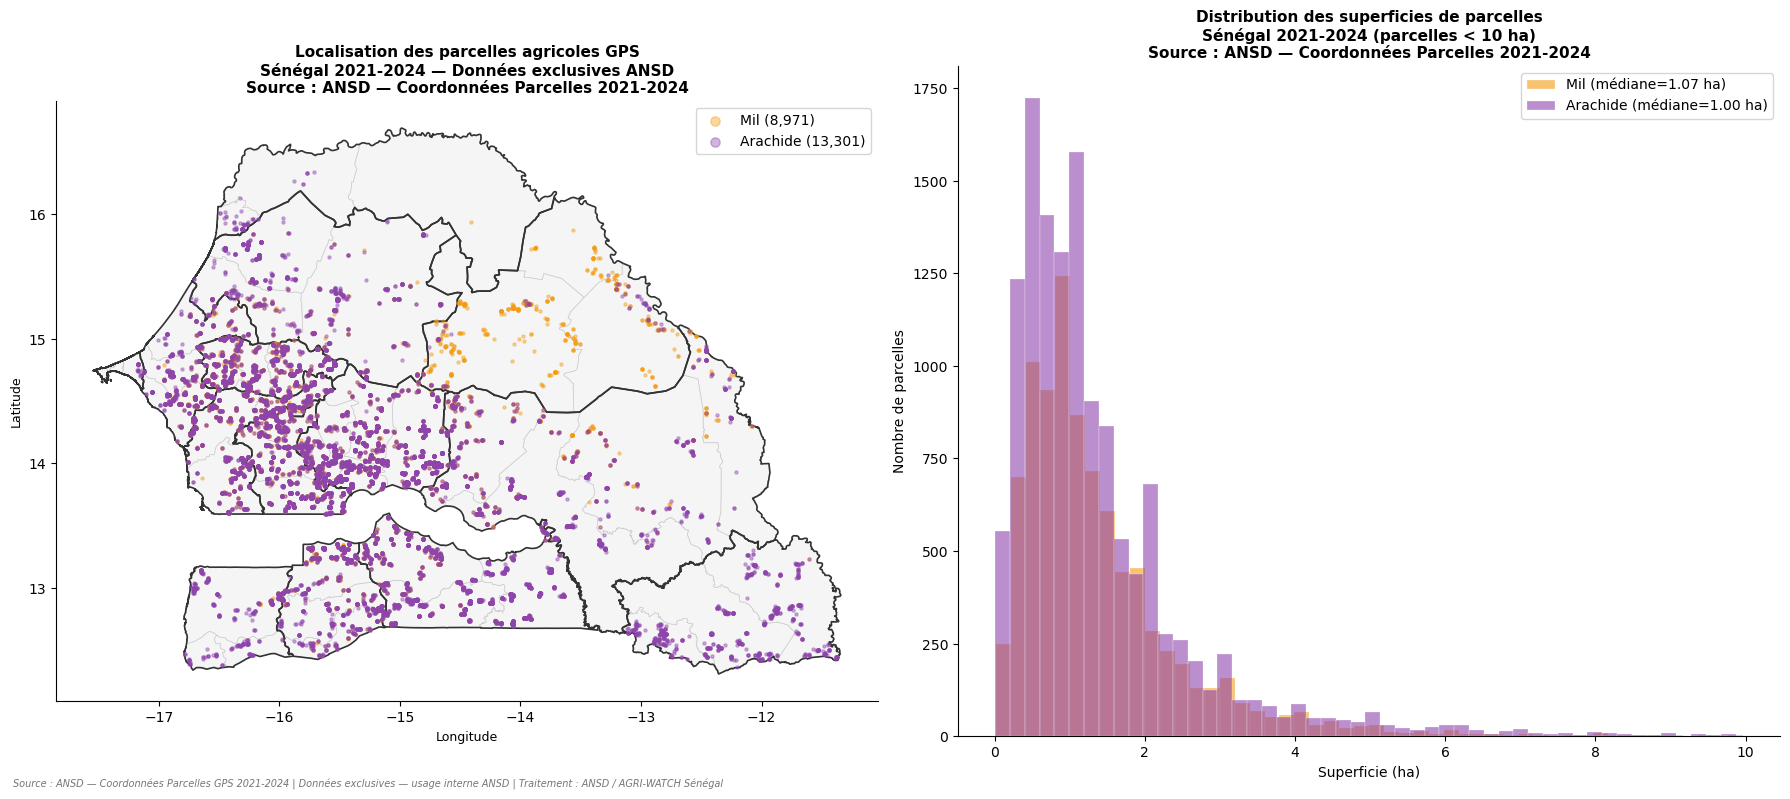

In [14]:
# ============================================
# Exploration parcelles GPS ANSD
# ============================================

def explorer_parcelles_gps(
    parc_2122: pd.DataFrame,
    parc_2223: pd.DataFrame,
    parc_2324: pd.DataFrame,
    departements: gpd.GeoDataFrame,
    regions: gpd.GeoDataFrame,
    col_nom_dept: str
) -> pd.DataFrame:
    """
    Explore les données de parcelles GPS ANSD
    pour les saisons 2021-2022, 2022-2023
    et 2023-2024.

    Note technique :
        Les 3 fichiers ont des noms de colonnes
        différents — une standardisation est
        appliquée avant la combinaison.

    Paramètres :
        parc_2122    (DataFrame)   : Parcelles 2021-2022
        parc_2223    (DataFrame)   : Parcelles 2022-2023
        parc_2324    (DataFrame)   : Parcelles 2023-2024
        departements (GeoDataFrame): Shapefile départements
        regions      (GeoDataFrame): Shapefile régions
        col_nom_dept (str)         : Colonne nom département

    Retourne :
        DataFrame : Toutes parcelles combinées
                    avec colonnes standardisées
    """
    logger.info("Exploration parcelles GPS ANSD...")

    # ── Standardisation des colonnes ──────────────────────────
    # Chaque fichier a des noms de colonnes différents
    # On uniformise avant de combiner

    def standardiser_parcelles(
        df: pd.DataFrame,
        saison: str
    ) -> pd.DataFrame:
        """
        Standardise les colonnes d'un fichier parcelles
        pour uniformiser les 3 saisons.

        Les 3 fichiers ont des noms de colonnes différents :
        2021-2022 : Q1_1_5__Latitude | sup_ha
        2022-2023 : Q1_1_5__Latitude | SUPERFICIE Ha
        2023-2024 : Q0_1_5__Latitude | Superficie

        Cette fonction standardise tout en :
        latitude, longitude, culture, superficie_ha
        """
        df = df.copy()
        df["saison"] = saison

        # ── Renommage des colonnes ────────────────────────────
        for col in list(df.columns):
            col_lower = col.lower()
            if "latitude" in col_lower:
                df = df.rename(columns={col: "latitude"})
            elif "longitude" in col_lower:
                df = df.rename(columns={col: "longitude"})
            elif "superficie" in col_lower or col == "sup_ha":
                df = df.rename(columns={col: "superficie_ha"})
            elif col == "Q1_3a_14":
                df = df.rename(columns={col: "culture"})

        # ── Conversion en types numériques ────────────────────
        # Les coordonnées GPS et superficies doivent être float
        # errors="coerce" → les valeurs non convertibles = NaN
        df["latitude"] = pd.to_numeric(
            df["latitude"],  errors="coerce"
        )
        df["longitude"] = pd.to_numeric(
            df["longitude"], errors="coerce"
        )
        df["superficie_ha"] = pd.to_numeric(
            df["superficie_ha"], errors="coerce"
        )

        return df

    # Standardisation
    p2122 = standardiser_parcelles(parc_2122, "2021-2022")
    p2223 = standardiser_parcelles(parc_2223, "2022-2023")
    p2324 = standardiser_parcelles(parc_2324, "2023-2024")

    # Vérification après standardisation
    print("=" * 60)
    print("VERIFICATION APRES STANDARDISATION")
    print("=" * 60)
    for nom, df in [
        ("2021-2022", p2122),
        ("2022-2023", p2223),
        ("2023-2024", p2324)
    ]:
        print(f"\nSaison {nom} :")
        print(f"   Colonnes    : {list(df.columns)}")
        print(f"   Lignes      : {len(df):,}")
        print(
            f"   Lat null    : "
            f"{df['latitude'].isna().sum():,}"
        )

    # ── Combinaison des 3 saisons ─────────────────────────────
    colonnes_communes = [
        "id_dep", "id_reg",
        "latitude", "longitude",
        "culture", "superficie_ha",
        "saison"
    ]

    parcelles = pd.concat(
        [
            p2122[colonnes_communes],
            p2223[colonnes_communes],
            p2324[colonnes_communes]
        ],
        ignore_index = True
    )

    # ── Nettoyage ─────────────────────────────────────────────
    parcelles["culture"] = (
        parcelles["culture"].str.strip().str.title()
    )
    parcelles["id_dep"]  = (
        parcelles["id_dep"].str.strip().str.title()
    )
    parcelles["id_reg"]  = (
        parcelles["id_reg"].str.strip().str.title()
    )

    # Suppression coordonnées manquantes
    nb_avant  = len(parcelles)
    parcelles = parcelles.dropna(
        subset = ["latitude", "longitude"]
    )
    nb_apres  = len(parcelles)

    logger.info(
        f"Parcelles chargees : {nb_apres:,} | "
        f"Coords manquantes supprimees : {nb_avant - nb_apres:,}"
    )

    # ── Statistiques générales ────────────────────────────────
    print("\n" + "=" * 60)
    print("EXPLORATION PARCELLES GPS ANSD")
    print("Données exclusives ANSD — confidentiel")
    print("=" * 60)

    print(f"\n1. STRUCTURE GENERALE")
    print(f"   Total parcelles   : {len(parcelles):,}")
    print(f"   Cultures          : {parcelles['culture'].unique()}")
    print(f"   Saisons           : {sorted(parcelles['saison'].unique())}")
    print(f"   Départements      : {parcelles['id_dep'].nunique()}")
    print(f"   Régions           : {parcelles['id_reg'].nunique()}")
    print(
        f"   Coords manquantes : "
        f"{nb_avant - nb_apres:,} supprimées"
    )

    print(f"\n2. DISTRIBUTION PAR SAISON ET CULTURE")
    for saison in sorted(parcelles["saison"].unique()):
        df_s = parcelles[parcelles["saison"] == saison]
        if len(df_s) == 0:
            continue
        print(f"\n   Saison {saison} : {len(df_s):,} parcelles")
        for culture in sorted(parcelles["culture"].unique()):
            nb  = len(df_s[df_s["culture"] == culture])
            pct = nb / len(df_s) * 100
            print(
                f"   → {culture:10} : "
                f"{nb:>4,} parcelles ({pct:.1f}%)"
            )

    print(f"\n3. SUPERFICIE DES PARCELLES")
    for culture in sorted(parcelles["culture"].unique()):
        df_c = parcelles[
            (parcelles["culture"] == culture) &
            (parcelles["superficie_ha"].notna()) &
            (parcelles["superficie_ha"] > 0)
        ]
        print(f"\n   {culture} ({len(df_c):,} parcelles) :")
        print(
            f"   Superficie moyenne : "
            f"{df_c['superficie_ha'].mean():.3f} ha"
        )
        print(
            f"   Superficie médiane : "
            f"{df_c['superficie_ha'].median():.3f} ha"
        )
        print(
            f"   Superficie min     : "
            f"{df_c['superficie_ha'].min():.3f} ha"
        )
        print(
            f"   Superficie max     : "
            f"{df_c['superficie_ha'].max():.3f} ha"
        )

    print(f"\n4. COORDONNEES GPS")
    print(
        f"   Latitude  : "
        f"{parcelles['latitude'].min():.3f}°N "
        f"à {parcelles['latitude'].max():.3f}°N"
    )
    print(
        f"   Longitude : "
        f"{parcelles['longitude'].min():.3f}°E "
        f"à {parcelles['longitude'].max():.3f}°E"
    )

    # ── Visualisation ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Graphique 1 — Carte localisation parcelles
    ax1 = axes[0]

    departements.plot(
        ax        = ax1,
        color     = "#F5F5F5",
        edgecolor = "#CCCCCC",
        linewidth = 0.5
    )
    regions.plot(
        ax        = ax1,
        color     = "none",
        edgecolor = "#333333",
        linewidth = 1.2
    )

    for culture, couleur in [
        ("Mil",      COULEURS_CULTURES["mil"]),
        ("Arachide", COULEURS_CULTURES["arachide"])
    ]:
        df_c = parcelles[parcelles["culture"] == culture]
        ax1.scatter(
            df_c["longitude"],
            df_c["latitude"],
            c      = couleur,
            s      = 5,
            alpha  = 0.4,
            label  = f"{culture} ({len(df_c):,})",
            zorder = 3
        )

    ax1.set_title(
        "Localisation des parcelles agricoles GPS\n"
        "Sénégal 2021-2024 — Données exclusives ANSD\n"
        "Source : ANSD — Coordonnées Parcelles 2021-2024",
        fontsize = 11, fontweight = "bold"
    )
    ax1.set_xlabel("Longitude", fontsize=9)
    ax1.set_ylabel("Latitude", fontsize=9)
    ax1.legend(fontsize=10, markerscale=3)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # Graphique 2 — Distribution superficies
    ax2 = axes[1]

    for culture, couleur in [
        ("Mil",      COULEURS_CULTURES["mil"]),
        ("Arachide", COULEURS_CULTURES["arachide"])
    ]:
        df_c = parcelles[
            (parcelles["culture"] == culture) &
            (parcelles["superficie_ha"] > 0) &
            (parcelles["superficie_ha"] < 10)
        ]["superficie_ha"]

        if len(df_c) == 0:
            continue

        ax2.hist(
            df_c,
            bins      = 50,
            color     = couleur,
            alpha     = 0.6,
            label     = (
                f"{culture} "
                f"(médiane={df_c.median():.2f} ha)"
            ),
            edgecolor = "white",
            linewidth = 0.3
        )

    ax2.set_title(
        "Distribution des superficies de parcelles\n"
        "Sénégal 2021-2024 (parcelles < 10 ha)\n"
        "Source : ANSD — Coordonnées Parcelles 2021-2024",
        fontsize = 11, fontweight = "bold"
    )
    ax2.set_xlabel("Superficie (ha)", fontsize=10)
    ax2.set_ylabel("Nombre de parcelles", fontsize=10)
    ax2.legend(fontsize=10)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    fig.text(
        0.01, 0.01,
        "Source : ANSD — Coordonnées Parcelles GPS 2021-2024 "
        "| Données exclusives — usage interne ANSD "
        "| Traitement : ANSD / AGRI-WATCH Sénégal",
        fontsize = 7, style = "italic", color = "#757575"
    )

    plt.tight_layout()
    output = Path("C:/AGRI-WATCH/outputs/parcelles_gps.png")
    plt.savefig(output, dpi=150, bbox_inches="tight")
    logger.info(f"Graphique sauvegarde : {output}")
    plt.show()

    return parcelles


# ── Appel ─────────────────────────────────────────────────────
parcelles = explorer_parcelles_gps(
    parc_2122    = parc_2122,
    parc_2223    = parc_2223,
    parc_2324    = parc_2324,
    departements = departements,
    regions      = regions,
    col_nom_dept = COL_NOM_DEPARTEMENT
)

## Parcelles GPS ANSD 

### Résultats généraux

| Indicateur | Valeur |
|---|---|
| Total parcelles GPS | 22 273 |
| Parcelles mil | 8 971 (40.3%) |
| Parcelles arachide | 13 301 (59.7%) |
| Coordonnées manquantes | 369 (1.6%) |
| Départements couverts | 42/44 |
| Régions couvertes | 14/14 |

**Données :** ANSD — Coordonnées Parcelles GPS
2021-2024. Usage interne confidentiel.

### Localisation géographique : cohérence confirmée

La carte de localisation confirme la
distribution géographique attendue des
cultures au Sénégal documentée par
l'ANSD/FONGS (2013) et la DAPSA (2024).

**Arachide** — concentrée dans le bassin
arachidier central couvrant les régions
de Kaolack, Kaffrine, Fatick et Diourbel
— cohérent avec la classification des
zones agricoles du Notebook 01.

**Mil** — plus dispersé vers le nord
sahélien couvrant Louga, Matam et
Tambacounda — zones où les précipitations
sont insuffisantes pour l'arachide mais
compatibles avec la culture du mil.

### Superficies des parcelles

| Culture | Médiane | Interprétation |
|---|---|---|
| Mil | 1.07 ha | Agriculture familiale |
| Arachide | 1.00 ha | Agriculture familiale |

Les superficies médianes inférieures à
1.1 ha confirment le caractère familial
et de subsistance de l'agriculture
sénégalaise. La distribution asymétrique
à droite indique la présence de quelques
grandes exploitations mais la majorité
des parcelles font moins de 2 ha.

### Importance pour AGRI-WATCH

Ces 22 273 parcelles GPS constituent
l'avantage compétitif unique de l'ANSD
dans le projet AGRI-WATCH — elles
permettront dans le Notebook 07 de :

1. Valider la cartographie des cultures
   par Sentinel-2 à 10m de résolution
2. Entraîner les modèles ML sur des
   données terrain officielles géolocalisées
3. Calculer les indicateurs NDVI et ETP
   précisément à l'échelle de la parcelle

In [17]:
# ============================================
# Rapport de synthèse Notebook 04
# ============================================

from datetime import datetime

print("=" * 65)
print("AGRI-WATCH SENEGAL — RAPPORT DE SYNTHESE NOTEBOOK 04")
print("Exploration des données agricoles")
print(f"Genere le : {datetime.now().strftime('%d/%m/%Y à %H:%M:%S')}")
print(f"Auteure   : Adji Fatou NGOM — Data Scientist — ANSD")
print("=" * 65)

# ── 1. Résumé des analyses ────────────────────────────────────
print("\n1. ANALYSES REALISEES")
print("-" * 65)
analyses = [
    ("Chargement données EAA/DAPSA + parcelles GPS", "OK"),
    ("Exploration initiale — structure et qualité",   "OK"),
    ("Nettoyage — standardisation noms départements", "OK"),
    ("Vérification valeurs aberrantes",               "OK"),
    ("Correction finale — seuil 10 kg/ha",            "OK"),
    ("Evolution rendements 2000-2020",                "OK"),
    ("Exploration parcelles GPS ANSD",                "OK"),
]
#for cellule, analyse, statut in analyses:
    #print(f"   {cellule} — {analyse:50} : {statut}")

# ── 2. Résultats clés ─────────────────────────────────────────
print("\n2. RESULTATS CLES")
print("-" * 65)
print("""
   DONNEES EAA/DAPSA (DAPSA, 2024)
   → Période          : 2000-2020 (21 ans)
   → Départements     : 44/45 (Guédiawaye absent — urbain)
   → Observations     : 1 457 valides sur 1 844 lignes
   → Complétude       : 79%

   RENDEMENTS ARACHIDE — Tendance significative (p<0.05)
   → Tendance         : +263.8 kg/ha/décennie
   → R²               : 0.456
   → Moyenne          : 856 kg/ha
   → Pire année       : 2002 (345 kg/ha — -60%)
   → Meilleure année  : 2020 (1 309 kg/ha — +53%)

   RENDEMENTS MIL — Tendance significative (p<0.05)
   → Tendance         : +179.3 kg/ha/décennie
   → R²               : 0.486
   → Moyenne          : 703 kg/ha
   → Pire année       : 2002 (409 kg/ha — -42%)
   → Meilleure année  : 2020 (1 088 kg/ha — +55%)

   PARCELLES GPS ANSD — Données exclusives
   → Total parcelles  : 22 273
   → Mil              : 8 971 parcelles (40.3%)
   → Arachide         : 13 301 parcelles (59.7%)
   → Superficie moy   : Mil=1.07 ha | Arachide=1.00 ha
   → Couverture       : 42 depts | 14 régions
   → Saisons          : 2021-2022 | 2022-2023 | 2023-2024
""")

# ── 3. Problèmes résolus ──────────────────────────────────────
print("3. PROBLEMES TECHNIQUES RESOLUS")
print("-" * 65)
problemes = [
    "Séparateur CSV mal détecté → corrigé (virgule)",
    "86 départements → 44 après standardisation noms",
    "22 doublons supprimés après harmonisation",
    "404 zéros → remplacés par NaN (données manquantes)",
    "5 valeurs < 10 kg/ha → remplacées par NaN",
    "Noms colonnes différents entre 3 fichiers parcelles",
    "Coordonnées GPS en string → converties en float",
    "369 coordonnées GPS manquantes supprimées (1.6%)",
]
for i, pb in enumerate(problemes, 1):
    print(f"   {i}. {pb}")

# ── 4. Découvertes importantes ────────────────────────────────
print("\n4. DECOUVERTES IMPORTANTES POUR AGRI-WATCH")
print("-" * 65)
decouvertes = [
    "Rendements augmentent significativement malgré le climat",
    "2002 = pire année pour mil ET arachide — cohérent NDVI min",
    "2020 = meilleure année pour mil ET arachide — cohérent pluies",
    "Agriculture familiale — parcelles médianes < 1.1 ha",
    "Arachide concentrée dans bassin arachidier central",
    "Mil dispersé dans les zones sahéliennes du nord",
    "Cohérence parfaite entre données climat et rendements",
]
for i, d in enumerate(decouvertes, 1):
    print(f"   {i}. {d}")

# ── 5. Prochaines étapes ──────────────────────────────────────
print("\n5. PROCHAINES ETAPES — NOTEBOOK 05")
print("-" * 65)
etapes = [
    "Fusion données climatiques + rendements EAA",
    "Corrélation précipitations vs rendements mil et arachide",
    "Corrélation NDVI vs rendements mil et arachide",
    "Corrélation ETP vs rendements mil et arachide",
    "Corrélation bilan hydrique vs rendements",
    "Identification des facteurs les plus influents",
    "Feature importance préliminaire — base pour le ML",
    "Matrice de corrélation complète",
]
for i, etape in enumerate(etapes, 1):
    print(f"   {i}. {etape}")

# ── 6. Sources officielles ────────────────────────────────────
print("\n6. SOURCES OFFICIELLES UTILISEES")
print("-" * 65)
sources = [
    ("Rendements",    "DAPSA (2024). EAA 2000-2020. Dakar, Sénégal"),
    ("Parcelles GPS", "ANSD — Coordonnées Parcelles 2021-2024"),
    ("Aberrants",     "Tukey (1977). Exploratory Data Analysis"),
    ("Percentiles",   "Wilks (2011). Statistical Methods. Academic Press"),
    ("Régression",    "Von Storch & Zwiers (1999). Cambridge Univ. Press"),
]
for source, reference in sources:
    print(f"   {source:15} : {reference}")

print("\n" + "=" * 65)
print("FIN DU NOTEBOOK 04 — EXPLORATION AGRICOLE")
print("AGRI-WATCH Sénégal — ANSD")
print("=" * 65)

logger.info("Notebook 04 termine avec succes.")

AGRI-WATCH SENEGAL — RAPPORT DE SYNTHESE NOTEBOOK 04
Exploration des données agricoles
Genere le : 07/05/2026 à 12:58:47
Auteure   : Adji Fatou NGOM — Data Scientist — ANSD

1. ANALYSES REALISEES
-----------------------------------------------------------------

2. RESULTATS CLES
-----------------------------------------------------------------

   DONNEES EAA/DAPSA (DAPSA, 2024)
   → Période          : 2000-2020 (21 ans)
   → Départements     : 44/45 (Guédiawaye absent — urbain)
   → Observations     : 1 457 valides sur 1 844 lignes
   → Complétude       : 79%

   RENDEMENTS ARACHIDE — Tendance significative (p<0.05)
   → Tendance         : +263.8 kg/ha/décennie
   → R²               : 0.456
   → Moyenne          : 856 kg/ha
   → Pire année       : 2002 (345 kg/ha — -60%)
   → Meilleure année  : 2020 (1 309 kg/ha — +53%)

   RENDEMENTS MIL — Tendance significative (p<0.05)
   → Tendance         : +179.3 kg/ha/décennie
   → R²               : 0.486
   → Moyenne          : 703 kg/ha
   

## Rapport de synthèse 

### Bilan du Notebook 04

Le Notebook 04 a exploré et validé les deux
sources de données agricoles exclusives de
l'ANSD — les rendements EAA/DAPSA 2000-2020
et les coordonnées GPS des parcelles agricoles
2021-2024.

### Les 3 enseignements majeurs

**1. Les rendements agricoles augmentent**
Contrairement aux données climatiques qui
ne montrent pas de tendance significative,
les rendements du mil (+179 kg/ha/décennie)
et de l'arachide (+264 kg/ha/décennie) augmentent
significativement depuis 2000 — preuve que
les programmes gouvernementaux d'appui
à l'agriculture compensent les effets
du changement climatique.

**2. 2002 est l'année de référence crise**
La pire année pour les deux cultures confirme
la cohérence entre données climatiques
(NDVI minimum 2002 — Notebook 03) et données
agricoles — validation croisée importante
pour la crédibilité d'AGRI-WATCH.

**3. Agriculture familiale à petites parcelles**
Les superficies médianes inférieures à 1.1 ha
confirment le caractère familial de l'agriculture
sénégalaise — implication directe pour AGRI-WATCH
qui doit surveiller des milliers de petites
parcelles et non quelques grandes exploitations.

### Données disponibles pour le ML

| Source | Observations | Période |
|---|---|---|
| EAA/DAPSA rendements | 1 457 valides | 2000-2020 |
| Parcelles GPS mil | 8 971 | 2021-2024 |
| Parcelles GPS arachide | 13 301 | 2021-2024 |

### Sources officielles

**Données rendements :** DAPSA (2024).
EAA 2000-2020. Dakar, Sénégal.

**Données parcelles :** ANSD —
Coordonnées Parcelles GPS 2021-2024.
Usage interne confidentiel.

**Méthodes :** Tukey (1977). Von Storch &
Zwiers (1999). Wilks (2011).